# SVM for classification

Load IRIS dataset, check its contents:


In [1]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [2]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [3]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

1.0

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [7]:
import numpy as np
from sklearn.datasets import load_iris
iris = load_iris()


X = iris.data[:, :2]
y = iris.target

print("First 5 rows of X:")
print(X[:5])
print("First 5 labels:")
print(y[:5])

mask = y != 2
X_binary = X[mask]
y_binary = y[mask]

print("Shapes after removing class 2:")
print(X_binary.shape, y_binary.shape)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

from sklearn.svm import SVC
SVMmodel = SVC(kernel='linear')
SVMmodel.fit(X_train, y_train)

print("Model accuracy:", SVMmodel.score(X_test, y_test))


First 5 rows of X:
[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]
First 5 labels:
[0 0 0 0 0]
Shapes after removing class 2:
(100, 2) (100,)
Train shape: (80, 2)
Test shape: (20, 2)
Model accuracy: 1.0


Plot scatterplots of targets 0 and 1 and check the separability of the classes:

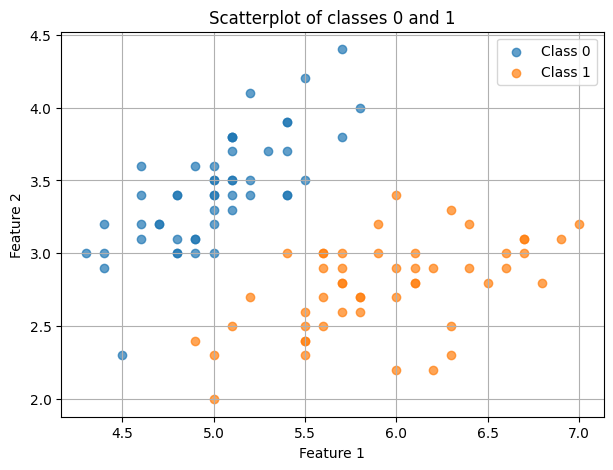

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(X_binary[y_binary == 0, 0], X_binary[y_binary == 0, 1], label="Class 0", alpha=0.7)
plt.scatter(X_binary[y_binary == 1, 0], X_binary[y_binary == 1, 1], label="Class 1", alpha=0.7)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatterplot of classes 0 and 1")
plt.legend()
plt.grid(True)
plt.show()

Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

In [10]:
from sklearn.svm import SVC

for C_value in [1, 10, 50, 100, 200]:
    model = SVC(kernel='linear', C=C_value)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"C = {C_value}, accuracy = {score:.4f}")


C = 1, accuracy = 1.0000
C = 10, accuracy = 1.0000
C = 50, accuracy = 1.0000
C = 100, accuracy = 1.0000
C = 200, accuracy = 1.0000


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

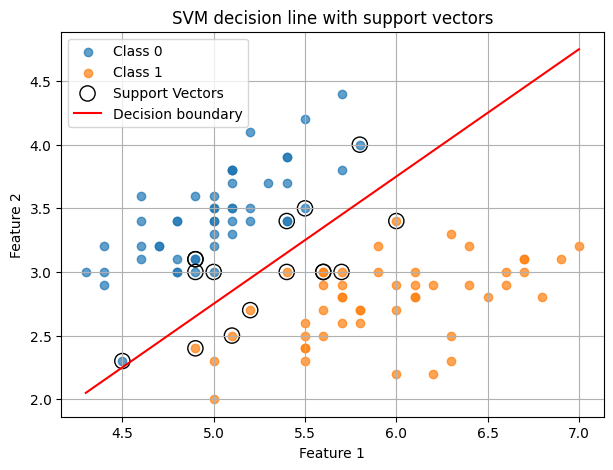

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(X_binary[y_binary == 0, 0], X_binary[y_binary == 0, 1], label="Class 0", alpha=0.7)
plt.scatter(X_binary[y_binary == 1, 0], X_binary[y_binary == 1, 1], label="Class 1", alpha=0.7)

plt.scatter(supvectors[:, 0], supvectors[:, 1],
            s=120, facecolors='none', edgecolors='black', label="Support Vectors")

x_vals = np.linspace(min(X_binary[:,0]), max(X_binary[:,0]), 100)
y_vals = -(W[0,0] * x_vals + b[0]) / W[0,1]

plt.plot(x_vals, y_vals, 'r-', label="Decision boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM decision line with support vectors")
plt.legend()
plt.grid(True)
plt.show()


# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

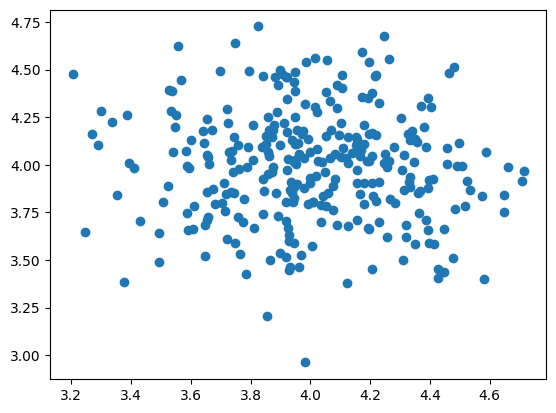

In [14]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

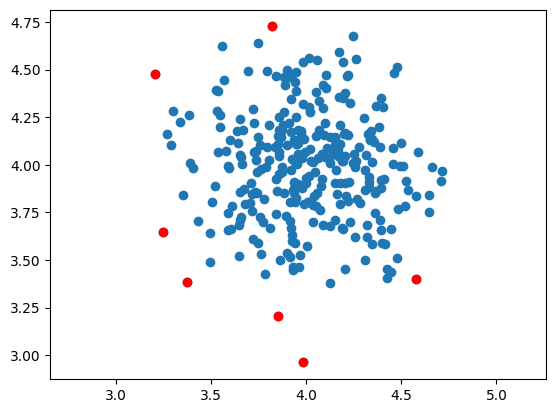

In [15]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

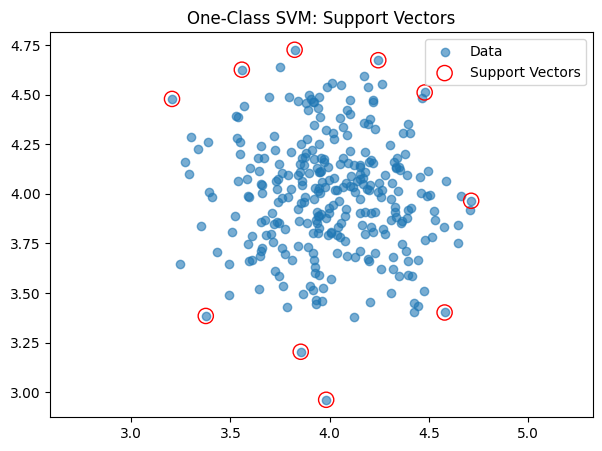

In [19]:
supvectors = SVMmodelOne.support_vectors_

plt.figure(figsize=(7,5))
plt.scatter(x[:,0], x[:,1], label="Data", alpha=0.6)

plt.scatter(supvectors[:,0], supvectors[:,1],
            s=120, facecolors='none', edgecolors='red', label="Support Vectors")

plt.title("One-Class SVM: Support Vectors")
plt.legend()
plt.axis('equal')
plt.show()


What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

8.987833799021839


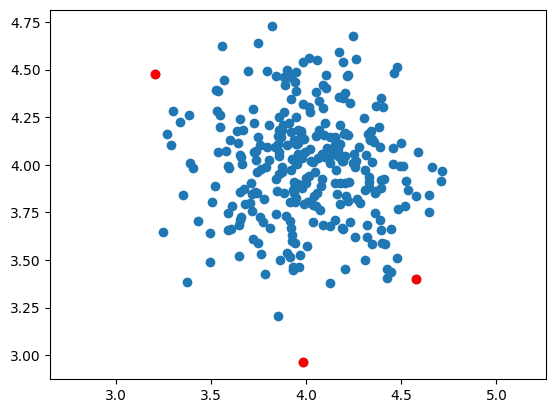

In [21]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.01)
print(thresh)
index = where(scores<=thresh)
values = x[index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()